# Spotify Music Analysis

## Objective
To investigate what makes a song popular on Spotify and which 
audio characteristics are most closely associated with popularity.

## Dataset
- Source: Kaggle — Spotify Tracks Dataset
- 114,000 tracks, 21 columns
- Time range: current Spotify catalog

## Stack
Python: pandas, matplotlib, seaborn

In [117]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


## Block A — Getting to know the dataset
Load the data and check the structure: size, 
data types, missing values, and duplicates.

In [118]:
df = pd.read_csv('dataset.csv')

In [119]:
print(df.shape)

(114000, 21)


In [120]:
print(df.dtypes)

Unnamed: 0            int64
track_id                str
artists                 str
album_name              str
track_name              str
popularity            int64
duration_ms           int64
explicit               bool
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature        int64
track_genre             str
dtype: object


In [121]:
print(df.head())

   Unnamed: 0                track_id                 artists  \
0           0  5SuOikwiRyPMVoIQDJUgSV             Gen Hoshino   
1           1  4qPNDBW1i3p13qLCt0Ki3A            Ben Woodward   
2           2  1iJBSr7s7jYXzM8EGcbK5b  Ingrid Michaelson;ZAYN   
3           3  6lfxq3CG4xtTiEg7opyCyx            Kina Grannis   
4           4  5vjLSffimiIP26QG5WcN2K        Chord Overstreet   

                                          album_name  \
0                                             Comedy   
1                                   Ghost (Acoustic)   
2                                     To Begin Again   
3  Crazy Rich Asians (Original Motion Picture Sou...   
4                                            Hold On   

                   track_name  popularity  duration_ms  explicit  \
0                      Comedy          73       230666     False   
1            Ghost - Acoustic          55       149610     False   
2              To Begin Again          57       210826     False   


In [123]:
print(df.isnull().sum())

Unnamed: 0          0
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64


In [124]:
print(df.duplicated().sum())

0


In [125]:
print(df.duplicated(subset=['track_id']).sum())

24259


In [126]:
df = df.dropna(subset=['artists', 'album_name', 'track_name'])
print(df.shape)

(113999, 21)


### Conclusions
- The dataset contains 114,000 tracks and 21 columns
- 1 row with missing values ​​was found — removed
- There are no complete duplicates, but 24,259 tracks 
occur in multiple genres at the same time
- df_unique was created for correlation analysis 
(80,293 unique tracks)

## Block B — Distribution of Characteristics
We investigate the distribution of popularity and basic 
audio characteristics of tracks.

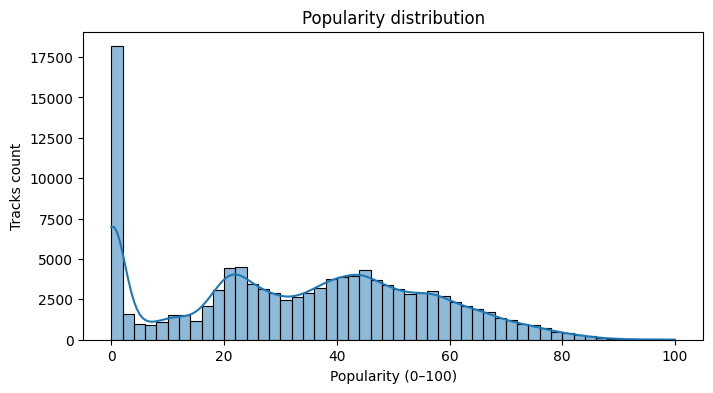

In [136]:
plt.figure(figsize=(8, 4))
sns.histplot(df['popularity'], bins=50, kde=True)
plt.title('Popularity distribution')
plt.xlabel('Popularity (0–100)')
plt.ylabel('Tracks count')
plt.show()

### Popularity
The distribution is heavily skewed to the right. The large peak near zero 
(~18,000 tracks) indicates a large number of 
little-known tracks. The median popularity is ~35, 
which means that half of the tracks have low popularity.

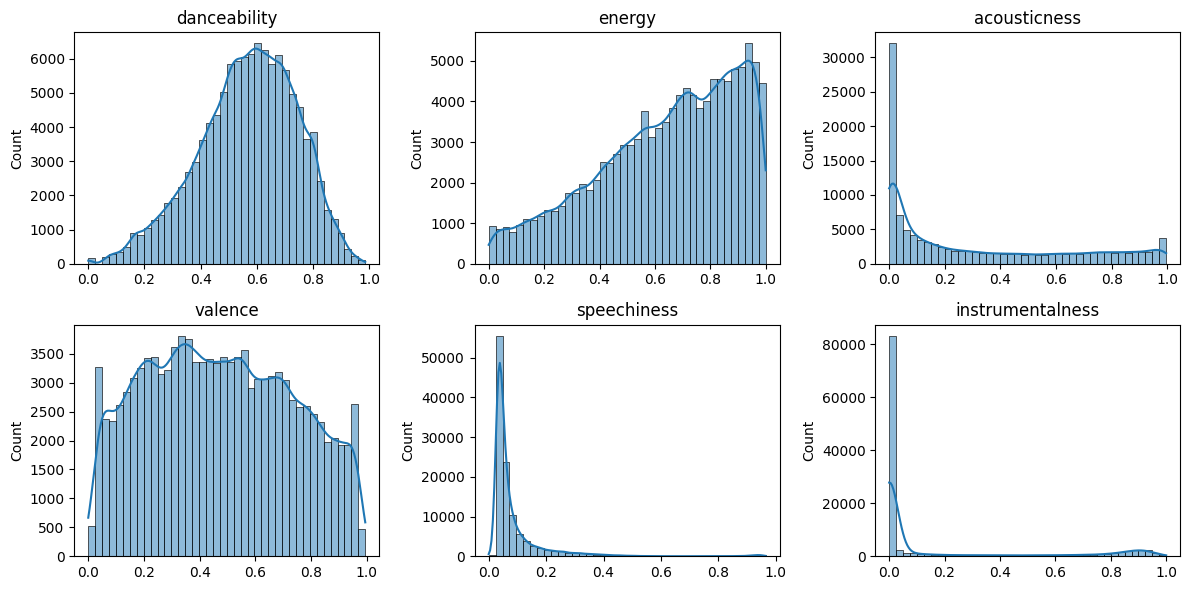

In [128]:
features = ['danceability', 'energy', 'acousticness', 
            'valence', 'speechiness', 'instrumentalness']

fig, axes = plt.subplots(2, 3, figsize=(12, 6))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.histplot(df[feature], bins=40, kde=True, ax=axes[i])
    axes[i].set_title(feature)
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()

### Audio characteristics
- **danceability** — close to normal distribution, 
most tracks are moderately danceable
- **energy** — skewed to the left, Spotify catalog is mostly 
energetic
- **speechiness** and **instrumentalness** — extremely 
skewed to zero, most tracks are music with vocals
- **valence** — almost uniform distribution, positive 
and negative tracks are equally represented

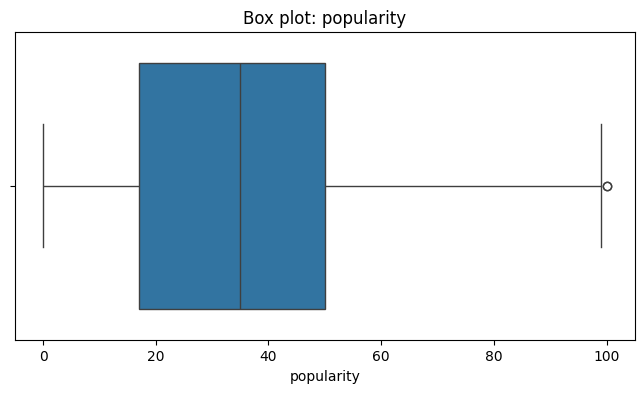

In [129]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['popularity'])
plt.title('Box plot: popularity')
plt.show()

## Block C — Correlation with popularity
We investigate the relationship between audio characteristics and 
popularity. We use df_unique to avoid 
double counting of tracks from multiple genres.

In [130]:
df_unique = df.drop_duplicates(subset=['track_id'])
df_unique = df_unique[df_unique['popularity'] > 0]
print(df_unique.shape)

(80293, 21)


In [132]:
r = ['popularity','danceability','energy','loudness','speechiness','instrumentalness','liveness','valence']
corr_matrix = df_unique[r].corr()
corr_matrix

,popularity,danceability,energy,loudness,speechiness,instrumentalness,liveness,valence
popularity,1.000000,0.074163,-0.034196,0.073137,-0.085061,-0.194921,-0.050307,-0.001856
danceability,0.074163,1.000000,0.110224,0.242824,0.105137,-0.176902,-0.139554,0.480284
energy,-0.034196,0.110224,1.000000,0.756251,0.136274,-0.180538,0.187836,0.241034
loudness,0.073137,0.242824,0.756251,1.000000,0.050680,-0.432005,0.078132,0.272365
speechiness,-0.085061,0.105137,0.136274,0.050680,1.000000,-0.105430,0.231552,0.031196
instrumentalness,-0.194921,-0.176902,-0.180538,-0.432005,-0.105430,1.000000,-0.097112,-0.324095
liveness,-0.050307,-0.139554,0.187836,0.078132,0.231552,-0.097112,1.000000,0.012107
valence,-0.001856,0.480284,0.241034,0.272365,0.031196,-0.324095,0.012107,1.000000


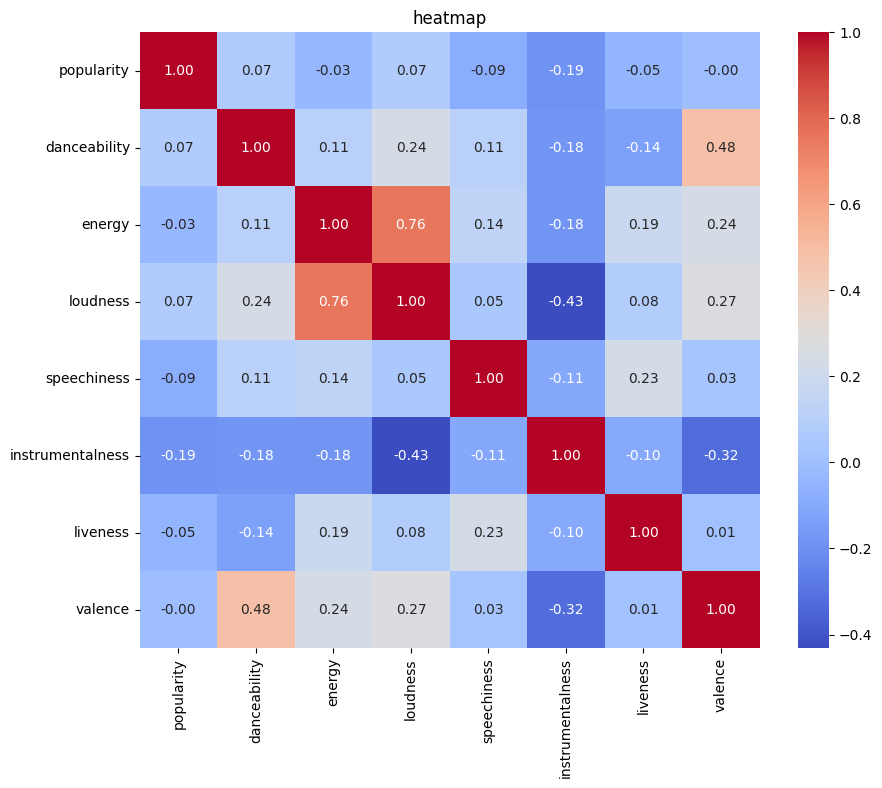

In [133]:
plt.figure(figsize = (10,8))
sns.heatmap(corr_matrix, cmap = 'coolwarm',fmt='.2f',annot=True)
plt.title('heatmap')
plt.show()

### Correlation matrix
No characteristic has a strong correlation with 
popularity — the highest values:
- instrumentalness: -0.19 (tracks with vocals are more popular)
- danceability: +0.07
- loudness: +0.07

Also noticeable is a strong correlation between energy and loudness 
(0.76) — multicollinearity, both characteristics 
measure similarly.

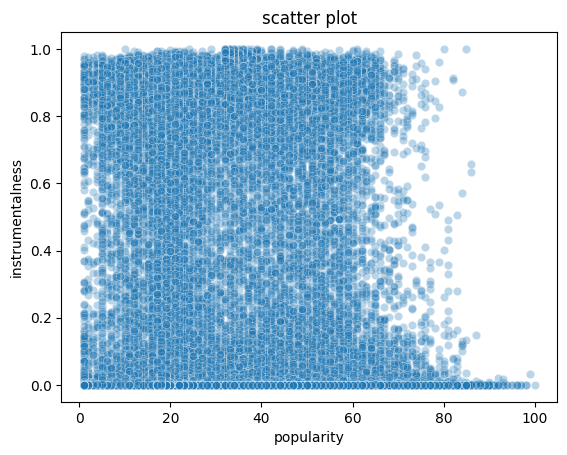

In [134]:
sns.scatterplot(x='popularity', y='instrumentalness', data=df_unique, alpha=0.3)
plt.title('scatter plot')
plt.show()

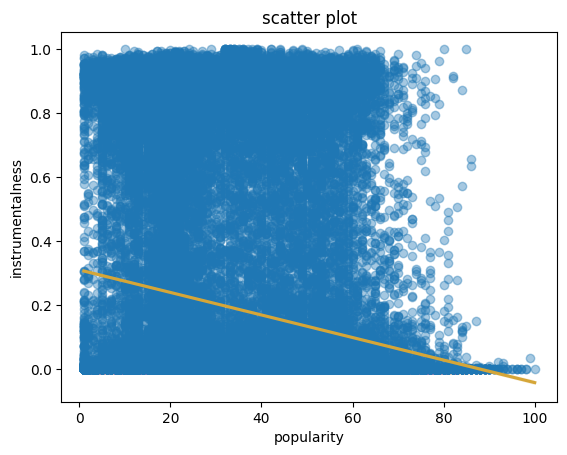

In [137]:
sns.regplot(x='popularity', y='instrumentalness', data=df_unique,scatter_kws={'alpha': 0.4},line_kws={'color': "#d5a638"})
plt.title('scatter plot')
plt.show()

### Instrumentalness vs Popularity
Tracks with high popularity (70+) almost exclusively have 
vocals (instrumentalness ≈ 0). Instrumental tracks 
rarely become hits on Spotify.

## Block D — Analysis by genres and artists
We investigate which genres and artists have the highest 
average popularity.

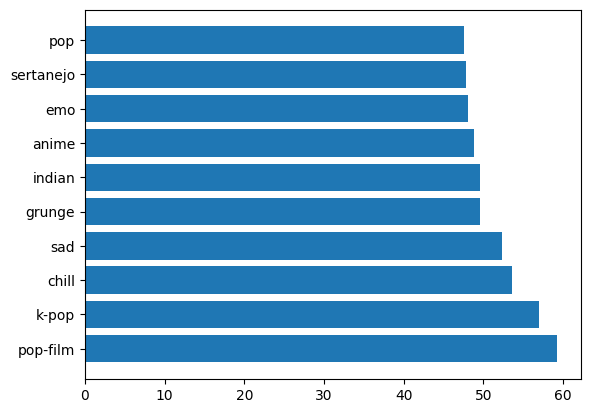

In [138]:
top_10_gen = df.groupby(["track_genre"])['popularity'].mean().sort_values(ascending=False).head(10)
plt.barh(top_10_gen.index,
         top_10_gen.values,
         )
plt.show()

### Top genres by popularity
Leaders: pop-film (59.3), k-pop (57.0), chill (53.7).
Pop-film is high because people search for songs after watching 
movies. Sertanejo is Brazilian country music, 
reflecting Spotify's large Brazilian audience.

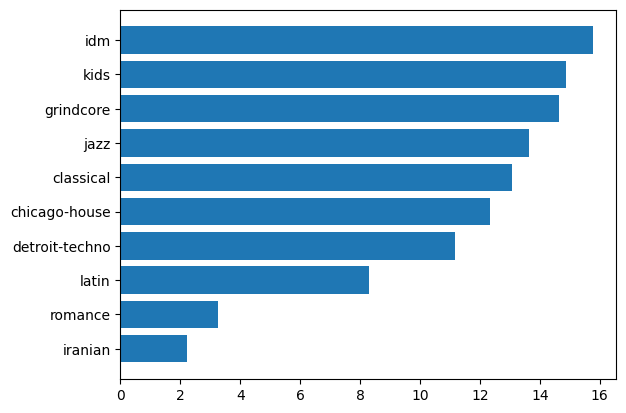

In [139]:
top_10_gen_end = df.groupby(["track_genre"])['popularity'].mean().sort_values().head(10)
plt.barh(top_10_gen_end.index,
         top_10_gen_end.values,
         )
plt.show()

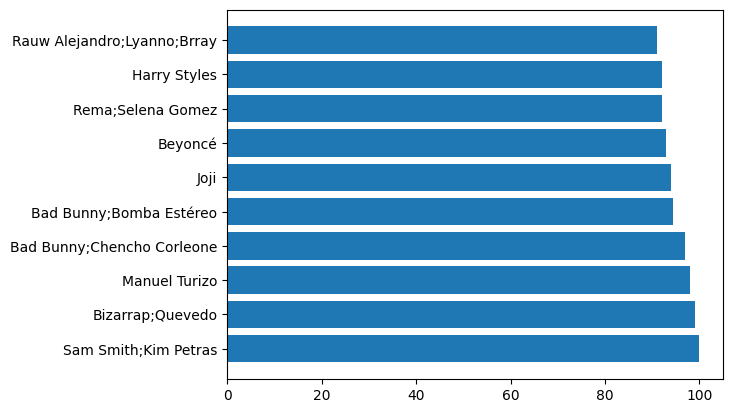

In [140]:
top_10_artist = df.groupby(["artists"])['popularity'].mean().sort_values(ascending=False).head(10)
plt.barh(top_10_artist.index,
         top_10_artist.values,
         )
plt.show()

### Top Artists
Most of the artists in the top are collaborations (Sam Smith & 
Kim Petras, Bizarrap & Quevedo). This is a limitation of the dataset: 
collaborations are recorded as a separate artist, so solo 
works by the same artists are counted separately.

## Additional analysis

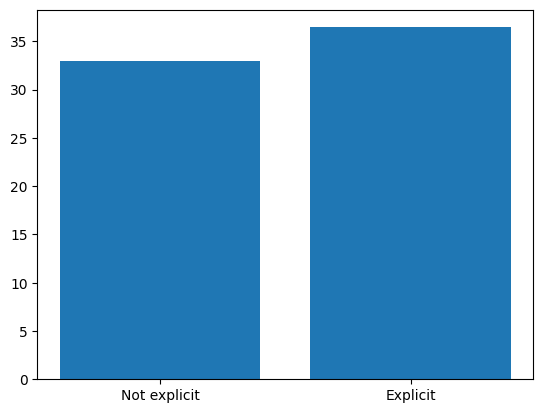

In [ ]:
ex = df.groupby(["explicit"])['popularity'].mean()
plt.bar(ex.index,
        ex.values)
plt.xticks([0, 1], ['Not explicit', 'Explicit'])
plt.show()

### Explicit content
Explicit tracks have a higher average popularity (36.4 vs 
32.9). The difference is small but consistent — most likely 
reflecting the dominance of hip-hop and R&B in the top charts.

In [ ]:
df_unique['duration_min'] = df_unique['duration_ms'] / 60000

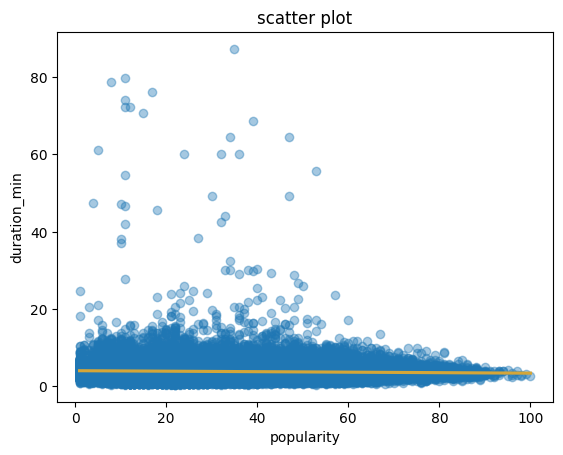

In [ ]:
sns.regplot(x='popularity', y='duration_min', data=df_unique,scatter_kws={'alpha': 0.4},line_kws={'color': "#d5a638"})
plt.title('scatter plot')
plt.show()


### Track Length
The trend line is almost horizontal — duration does not affect 
popularity. Most hits are 3-5 minutes long. 
Outliers (20-90 minutes) — ambient or classic with low 
popularity.

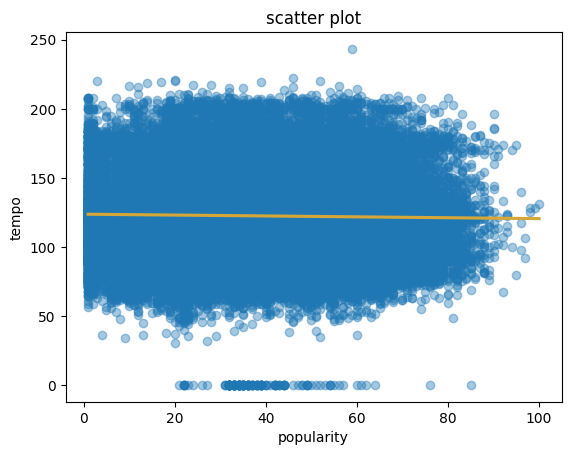

In [ ]:
sns.regplot(x='popularity', y='tempo', data=df_unique,scatter_kws={'alpha': 0.4},line_kws={'color': "#d5a638"})
plt.title('scatter plot')
plt.show()

### Tempo
There is no correlation with popularity. Hits can be both slow and fast - there is no "ideal BPM".

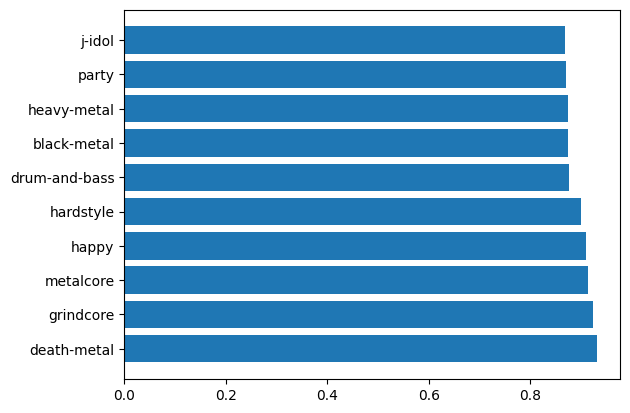

In [142]:
top_10_energy = df.groupby(["track_genre"])['energy'].mean().sort_values(ascending=False).head(10)
plt.barh(top_10_energy.index,
         top_10_energy.values,
         )
plt.show()

### Energy by genre
The most energetic: death-metal, grindcore, metalcore.
The most calm: classical, new-age, ambient, sleep.
The result fully meets expectations and confirms the 
quality of the data.

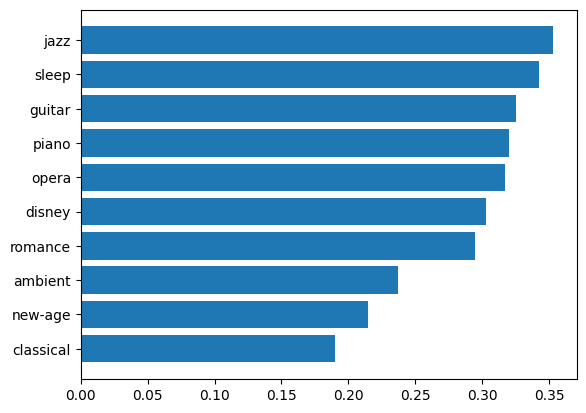

In [141]:
top_10_energy_end = df.groupby(["track_genre"])['energy'].mean().sort_values().head(10)
plt.barh(top_10_energy_end.index,
         top_10_energy_end.values,
         )
plt.show()

## General conclusions

1. **Popularity is hard to predict** — no single 
characteristic has a strong correlation
2. **Vocals matter** — instrumentalness has the strongest 
relationship with popularity (-0.19)
3. **Explicit content is slightly more popular** — reflects 
the dominance of hip-hop
4. **Length and tempo do not matter** — hits are 
different
5. **Genre affects popularity** — pop-film and k-pop 
lead, classical and jazz at the bottom